In [7]:
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import mutual_info_regression
from xgboost import XGBRegressor


In [8]:
# Kaggle path
df = pd.read_csv("ames.csv")

X = df.copy()
y = X.pop("SalePrice")


In [9]:
# Features fortement corrélées
pca_features = ["GrLivArea", "TotalBsmtSF", "GarageArea"]

X_pca_base = X[pca_features]

# Standardisation
X_pca_scaled = (X_pca_base - X_pca_base.mean()) / X_pca_base.std()

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_pca_scaled)

# Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_features,
    columns=[f"PC{i+1}" for i in range(len(pca_features))]
)

print("PCA Loadings:")
print(loadings)
print("\nExplained variance:")
print(pca.explained_variance_ratio_)


PCA Loadings:
                  PC1       PC2       PC3
GrLivArea    0.571657  0.714598 -0.403185
TotalBsmtSF  0.572350 -0.699397 -0.428088
GarageArea   0.587897 -0.013956  0.808815

Explained variance:
[0.64778895 0.18496952 0.16724153]


In [10]:
# ===== FEATURE ENGINEERING FINAL =====

X = df.copy()
y = X.pop("SalePrice")

# PC1 → Taille globale
X["TotalSF"] = X["GrLivArea"] + X["TotalBsmtSF"]

# PC3 → Configuration
X["LivingToBasementRatio"] = X["GrLivArea"] / (X["TotalBsmtSF"] + 1)


In [11]:
def score_dataset(X, y, model=XGBRegressor()):
    for col in X.select_dtypes(["object", "category"]):
        X[col], _ = X[col].factorize()

    score = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="neg_mean_squared_log_error"
    )
    score = -1 * score.mean()
    return np.sqrt(score)


In [12]:
score = score_dataset(X, y)
print(f"Your score: {score:.5f} RMSLE")


Your score: 0.14054 RMSLE


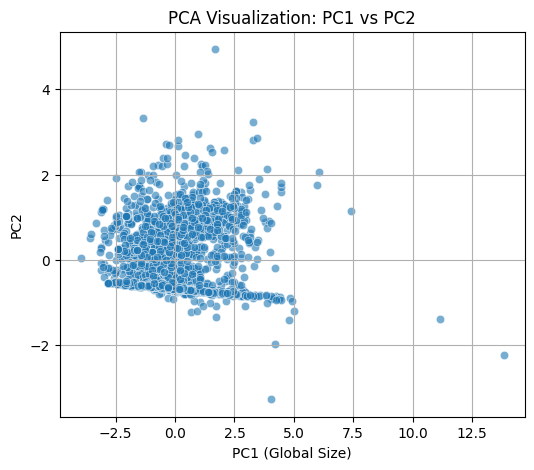

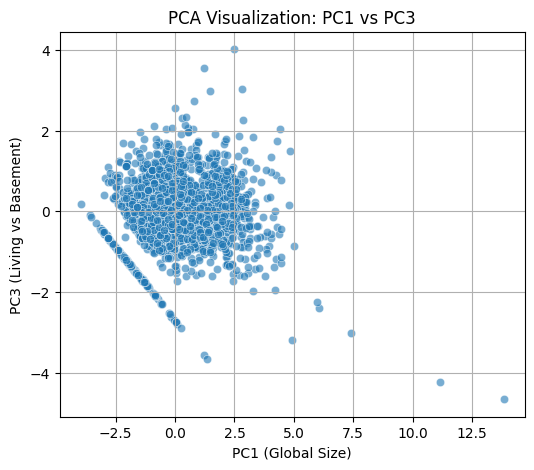

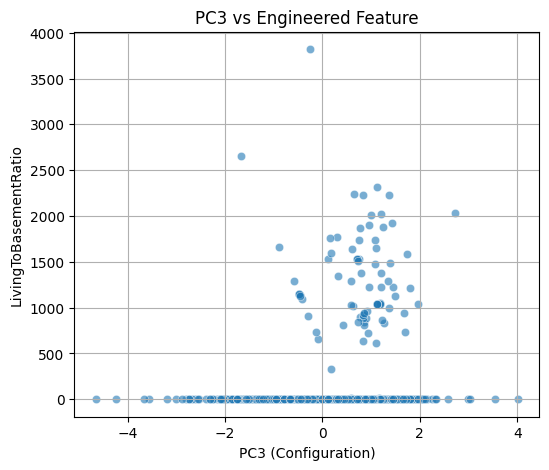

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Recalcul PCA pour visualisation (clair et propre)
pca_features = ["GrLivArea", "TotalBsmtSF", "GarageArea"]

X_vis = df[pca_features]
X_vis_scaled = (X_vis - X_vis.mean()) / X_vis.std()

pca = PCA(n_components=3)
X_pca_vis = pca.fit_transform(X_vis_scaled)

X_pca_vis = pd.DataFrame(
    X_pca_vis,
    columns=["PC1", "PC2", "PC3"]
)

# ===============================
# 1️⃣ PC1 vs PC2 (structure globale)
# ===============================
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=X_pca_vis["PC1"],
    y=X_pca_vis["PC2"],
    alpha=0.6
)
plt.xlabel("PC1 (Global Size)")
plt.ylabel("PC2")
plt.title("PCA Visualization: PC1 vs PC2")
plt.grid(True)
plt.show()

# ===============================
# 2️⃣ PC1 vs PC3 (configuration)
# ===============================
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=X_pca_vis["PC1"],
    y=X_pca_vis["PC3"],
    alpha=0.6
)
plt.xlabel("PC1 (Global Size)")
plt.ylabel("PC3 (Living vs Basement)")
plt.title("PCA Visualization: PC1 vs PC3")
plt.grid(True)
plt.show()

# ===============================
# 3️⃣ PC3 vs Living/Basement Ratio
# ===============================
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=X_pca_vis["PC3"],
    y=X["LivingToBasementRatio"],
    alpha=0.6
)
plt.xlabel("PC3 (Configuration)")
plt.ylabel("LivingToBasementRatio")
plt.title("PC3 vs Engineered Feature")
plt.grid(True)
plt.show()


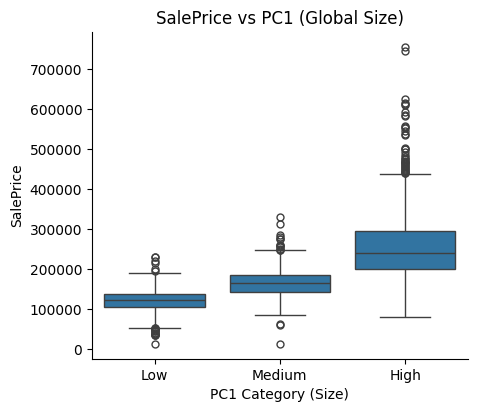

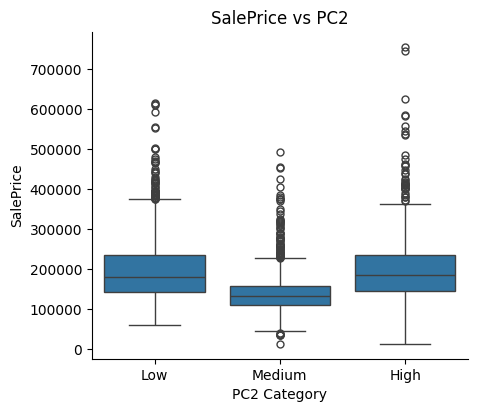

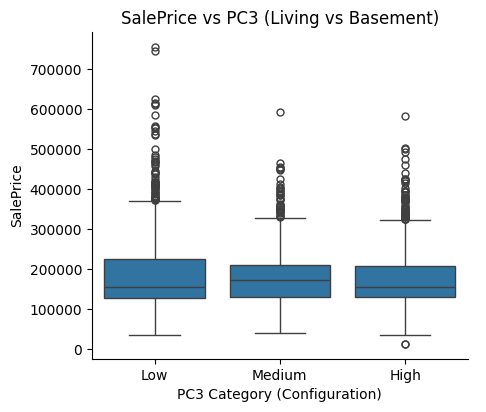

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ===============================
# Préparer les données PCA
# ===============================

# On suppose que X_pca_vis contient PC1, PC2, PC3
# et que y contient SalePrice

df_pca_plot = X_pca_vis.copy()
df_pca_plot["SalePrice"] = y.values

# Créer des catégories (quantiles) pour chaque PC
for pc in ["PC1", "PC2", "PC3"]:
    df_pca_plot[f"{pc}_bin"] = pd.qcut(
        df_pca_plot[pc],
        q=3,
        labels=["Low", "Medium", "High"]
    )

# ===============================
# CATPLOT – PC1 vs SalePrice
# ===============================
sns.catplot(
    data=df_pca_plot,
    x="PC1_bin",
    y="SalePrice",
    kind="box",
    height=4,
    aspect=1.2
)
plt.title("SalePrice vs PC1 (Global Size)")
plt.xlabel("PC1 Category (Size)")
plt.ylabel("SalePrice")
plt.show()

# ===============================
# CATPLOT – PC2 vs SalePrice
# ===============================
sns.catplot(
    data=df_pca_plot,
    x="PC2_bin",
    y="SalePrice",
    kind="box",
    height=4,
    aspect=1.2
)
plt.title("SalePrice vs PC2")
plt.xlabel("PC2 Category")
plt.ylabel("SalePrice")
plt.show()

# ===============================
# CATPLOT – PC3 vs SalePrice
# ===============================
sns.catplot(
    data=df_pca_plot,
    x="PC3_bin",
    y="SalePrice",
    kind="box",
    height=4,
    aspect=1.2
)
plt.title("SalePrice vs PC3 (Living vs Basement)")
plt.xlabel("PC3 Category (Configuration)")
plt.ylabel("SalePrice")
plt.show()
